In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
df = pd.read_csv("CICIDS_multiclass_processed.csv")

In [4]:
df.head()

,Bwd Packet Length Max,Flow Duration,Flow IAT Std,Flow IAT Mean,Bwd Packet Length Min,Bwd IAT Max,PSH Flag Count,Bwd IAT Std,FIN Flag Count,Min Packet Length,Flow IAT Min,ACK Flag Count,label_multi_enc
0,0.000000,0.000118,0.000092,0.000040,0.000000,0.000118,0.0,0.000000,1.0,0.000000,2.416666e-07,0.0,4
1,0.015207,0.000674,0.000238,0.000112,0.000000,0.000335,1.0,0.000271,0.0,0.000000,1.500000e-07,0.0,0
2,0.005581,0.002208,0.001027,0.000315,0.037638,0.001948,0.0,0.001598,0.0,0.030387,1.333333e-07,0.0,0
3,0.000000,0.000150,0.000150,0.000075,0.000000,0.000000,0.0,0.000000,1.0,0.004144,1.250000e-07,0.0,4
4,0.006349,0.000541,0.000000,0.000541,0.042818,0.000000,0.0,0.000000,0.0,0.036602,5.409083e-04,0.0,0


In [5]:
df.isnull().sum()

Bwd Packet Length Max    0
Flow Duration            0
Flow IAT Std             0
Flow IAT Mean            0
Bwd Packet Length Min    0
Bwd IAT Max              0
PSH Flag Count           0
Bwd IAT Std              0
FIN Flag Count           0
Min Packet Length        0
Flow IAT Min             0
ACK Flag Count           0
label_multi_enc          0
dtype: int64

In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2522362, 13)


In [7]:
df.columns

Index(['Bwd Packet Length Max', 'Flow Duration', 'Flow IAT Std',
       'Flow IAT Mean', 'Bwd Packet Length Min', 'Bwd IAT Max',
       'PSH Flag Count', 'Bwd IAT Std', 'FIN Flag Count', 'Min Packet Length',
       'Flow IAT Min', 'ACK Flag Count', 'label_multi_enc'],
      dtype='object')

In [8]:
print("\nClass distribution:")
print(df['label_multi_enc'].value_counts().sort_index())


Class distribution:
label_multi_enc
0     2096484
1        1953
2      128016
3       10286
4      172849
5        5228
6        5385
7        5933
8          11
9          36
10      90819
11       3219
12       1470
13         21
14        652
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['label_multi_enc'])
y = df['label_multi_enc']

# Stratified split (preserves class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Distribution check
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())


Train shape: (2017889, 12)
Test shape: (504473, 12)

Training class distribution:
label_multi_enc
0     1677187
1        1562
2      102413
3        8229
4      138279
5        4182
6        4308
7        4746
8           9
9          29
10      72655
11       2575
12       1176
13         17
14        522
Name: count, dtype: int64

Testing class distribution:
label_multi_enc
0     419297
1        391
2      25603
3       2057
4      34570
5       1046
6       1077
7       1187
8          2
9          7
10     18164
11       644
12       294
13         4
14       130
Name: count, dtype: int64


Because you have classes with very few samples (like class 8 = 9 samples, class 13 = 17 samples), normal SMOTE may fail (since it needs at least k_neighbors+1 samples).

If a class is too small for SMOTE, we fall back to RandomOverSampler.

Majority = class 0 (1.67M)

Medium classes = 2, 4, 10 (tens of thousands)

Minority = 8 (9 samples), 13 (17), 9 (29) → too tiny for SMOTE safely

In [10]:
from collections import Counter
import pandas as pd
from imblearn.over_sampling import SMOTE, RandomOverSampler

print("Before resampling:", Counter(y_train))

# find smallest class count
min_count = min(Counter(y_train).values())

# safe k_neighbors for SMOTE
k = min(5, max(1, min_count - 1))  

if min_count <= 5:  
    # too few samples for SMOTE → use random oversampling
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    print("Used RandomOverSampler (too few samples for SMOTE).")
else:
    sm = SMOTE(k_neighbors=k, random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print(f"Used SMOTE with k_neighbors={k}.")

print("After resampling:", Counter(y_train_res))
print("Resampled train shape:", X_train_res.shape)


Before resampling: Counter({0: 1677187, 4: 138279, 2: 102413, 10: 72655, 3: 8229, 7: 4746, 6: 4308, 5: 4182, 11: 2575, 1: 1562, 12: 1176, 14: 522, 9: 29, 13: 17, 8: 9})
Used SMOTE with k_neighbors=5.
After resampling: Counter({4: 1677187, 0: 1677187, 10: 1677187, 2: 1677187, 12: 1677187, 3: 1677187, 7: 1677187, 1: 1677187, 5: 1677187, 14: 1677187, 6: 1677187, 11: 1677187, 8: 1677187, 9: 1677187, 13: 1677187})
Resampled train shape: (25157805, 12)


##### DECISION TREE

Decision Tree Performance:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    419297
           1       0.04      0.88      0.07       391
           2       0.99      1.00      0.99     25603
           3       0.88      0.98      0.93      2057
           4       0.98      0.98      0.98     34570
           5       0.76      0.96      0.85      1046
           6       0.80      0.92      0.86      1077
           7       0.74      0.85      0.79      1187
           8       1.00      1.00      1.00         2
           9       0.31      0.57      0.40         7
          10       0.99      1.00      0.99     18164
          11       0.62      0.93      0.74       644
          12       0.09      0.57      0.15       294
          13       0.01      0.25      0.01         4
          14       0.27      0.39      0.32       130

    accuracy                           0.97    504473
   macro avg       0.63      0.82      0.67    504473

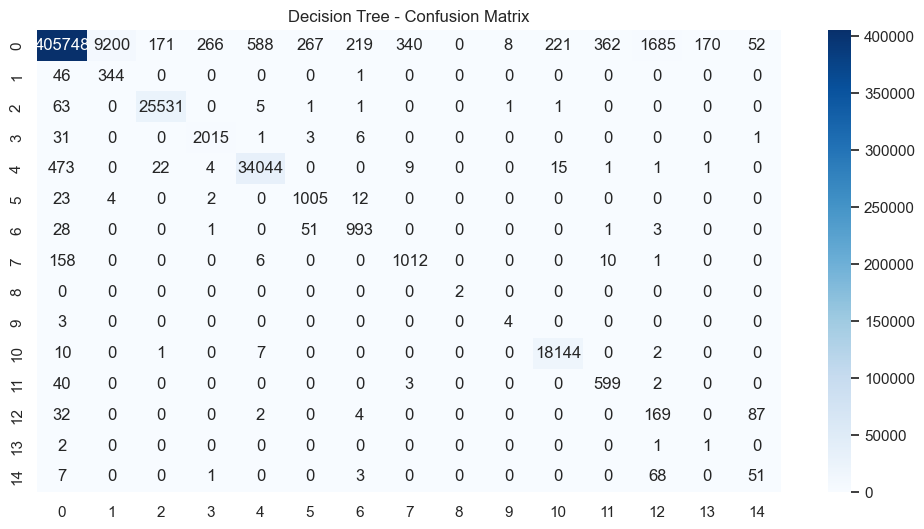

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

# Predictions on test set (NOT resampled, real distribution)
y_pred_dt = dt.predict(X_test)

# Classification report
print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


##### RANDOM FOREST

Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    419297
           1       0.04      0.91      0.07       391
           2       0.99      1.00      1.00     25603
           3       0.88      0.98      0.93      2057
           4       0.98      0.99      0.98     34570
           5       0.78      0.98      0.87      1046
           6       0.83      0.95      0.88      1077
           7       0.73      0.90      0.81      1187
           8       1.00      1.00      1.00         2
           9       0.80      0.57      0.67         7
          10       0.99      1.00      0.99     18164
          11       0.62      0.93      0.75       644
          12       0.09      0.54      0.15       294
          13       0.01      0.25      0.01         4
          14       0.30      0.39      0.34       130

    accuracy                           0.97    504473
   macro avg       0.67      0.82      0.70    504473

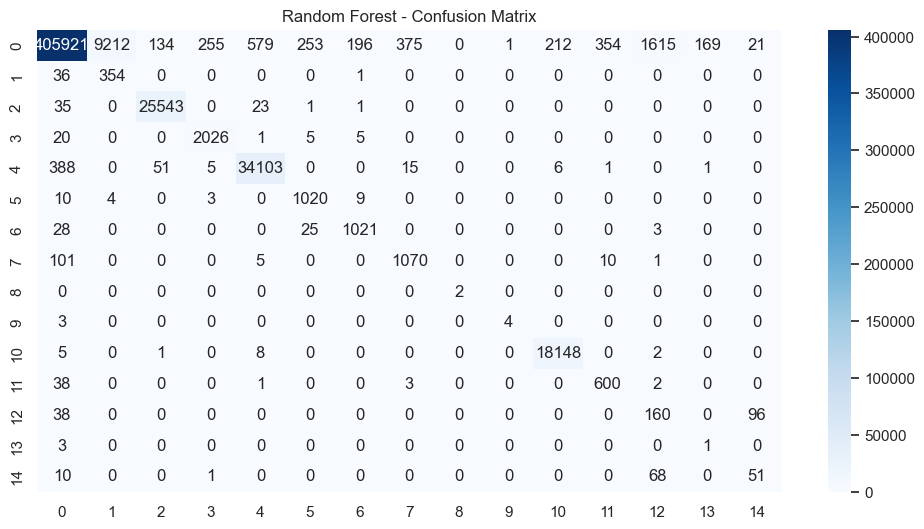

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest on SMOTE-balanced training set
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    class_weight=None,      # not needed since we used SMOTE
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf.fit(X_train_res, y_train_res)

# Predictions on real-world test set
y_pred_rf = rf.predict(X_test)

# Classification report
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf) 
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()


Class 1 (very rare) → recall stayed very high (0.91), but precision is still low → model finds positives, but too many false alarms.

Classes 5, 6, 7, 11, 12, 13, 14 → recall improved compared to Decision Tree.

Macro-average F1 (0.70) is better than DT’s 0.67 → showing that RF generalizes better.

Overall, RF is much more stable than a single Decision Tree (expected).

In [12]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 985.5 kB/s eta 0:00:58
   - -------------------------------------- 1.6/56.8 MB 2.7 MB/s eta 0:00:21
   - -------------------------------------- 1.8/56.8 MB 2.2 MB/s eta 0:00:26
   - -------------------------------------- 2.6/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.1/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.4/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 3.9/56.8 MB 2.4 MB/s eta 0:00:23
   --- ------------------------------------ 4.5/56.8 MB 2.5 MB/s eta 0:00:21
   --- ------------------------------------ 4.7/56.8 MB 2.4 MB/s eta 0:00:22
   --- ------------------------------------ 5.0/56.8 MB 2.3 MB/s eta 0:00:23
   --- ------------------------------------ 5.2/56.8 MB 2.2 MB/s eta 0:00:24
   --- ----

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:30:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    419297
           1       0.03      0.98      0.06       391
           2       0.99      1.00      0.99     25603
           3       0.61      1.00      0.76      2057
           4       0.95      0.99      0.97     34570
           5       0.55      0.98      0.71      1046
           6       0.88      0.97      0.92      1077
           7       0.53      0.98      0.69      1187
           8       1.00      1.00      1.00         2
           9       0.21      0.71      0.32         7
          10       0.99      1.00      0.99     18164
          11       0.09      0.95      0.17       644
          12       0.05      0.57      0.08       294
          13       0.00      0.75      0.00         4
          14       0.03      0.52      0.05       130

    accuracy                           0.92    504473
   macro avg       0.53      0.89      0.58    504473
weigh

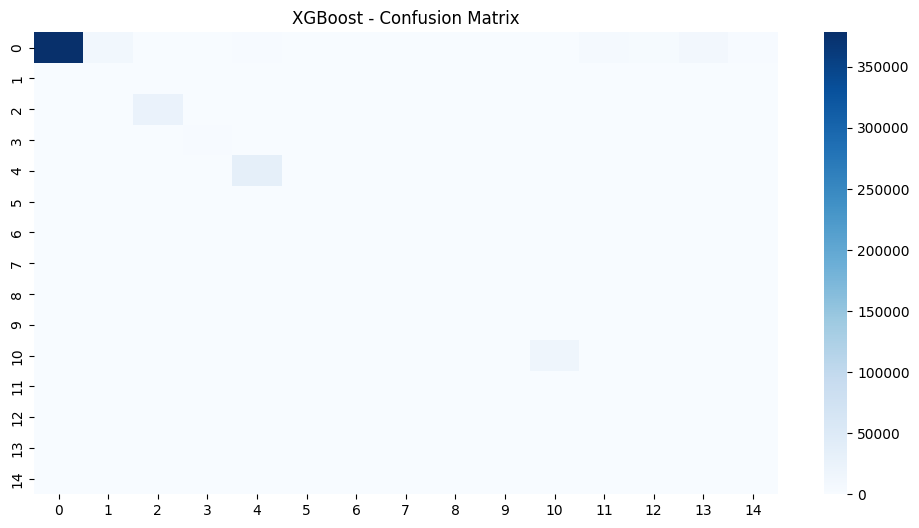

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,       # number of boosting rounds
    learning_rate=0.1,      # step size shrinkage
    max_depth=8,            # depth of each tree
    subsample=0.8,          # row sampling
    colsample_bytree=0.8,   # feature sampling
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_res, y_train_res)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Report
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()


##### LIGHTGBM

In [15]:
!pip install lightgbm 

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


SMOTE data not required

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2173
[LightGBM] [Info] Number of data points in the train set: 2017889, number of used features: 12
[LightGBM] [Info] Start training from score -0.184934
[LightGBM] [Info] Start training from score -7.163840
[LightGBM] [Info] Start training from score -2.980794
[LightGBM] [Info] Start training from score -5.502143
[LightGBM] [Info] Start training from score -2.680534
[LightGBM] [Info] Start training from score -6.179018
[LightGBM] [Info] Start training from score -6.149333
[LightGBM] [Info] Start training from score -6.052505
[LightGBM] [Info] Start training from score -12.320338
[LightGBM] [Info] Start training from score -11.150267
[LightGBM] [Info] Start

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

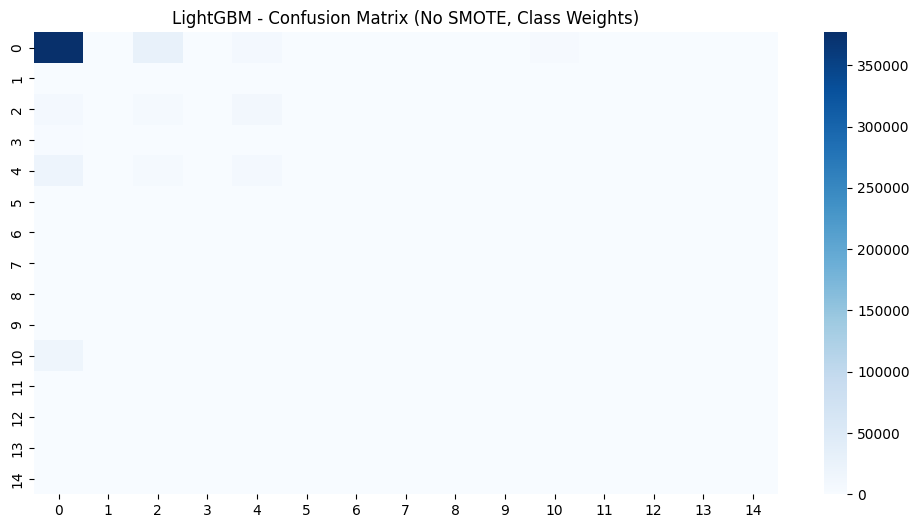

In [17]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train LightGBM without SMOTE, with class weighting
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=128,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,      # handles class imbalance
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)   #Note: use X_train, y_train (not SMOTE version)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Report
print("LightGBM Performance (with class weights, no SMOTE):")
print(classification_report(y_test, y_pred_lgbm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("LightGBM - Confusion Matrix (No SMOTE, Class Weights)")
plt.show()


#### LSTM

In [33]:
import numpy as np

# Convert train/test to numpy
X_train_lstm = np.array(X_train_res)
y_train_lstm = np.array(y_train_res)
X_test_lstm = np.array(X_test)
y_test_lstm = np.array(y_test)

# Reshape for LSTM: (samples, timesteps, features)
# Here timesteps = 1 (each row is one event)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], 1, X_train_lstm.shape[1]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], 1, X_test_lstm.shape[1]))

print("Train shape for LSTM:", X_train_lstm.shape)
print("Test shape for LSTM:", X_test_lstm.shape)


Train shape for LSTM: (25157805, 1, 12)
Test shape for LSTM: (504473, 1, 12)


Shape of data: (samples, timesteps, features)

In [21]:
!pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.8/331.9 MB 10.1 MB/s eta 0:00:33
    --------------------------------------- 4.2/331.9 MB 10.5 MB/s eta 0:00:32
    --------------------------------------- 6.6/331.9 MB 10.9 MB/s eta 0:00:30
   - -----------

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# One-hot encode labels for multiclass classification
num_classes = len(np.unique(y_train_lstm))
y_train_cat = to_categorical(y_train_lstm, num_classes=num_classes)
y_test_cat = to_categorical(y_test_lstm, num_classes=num_classes)

# Build LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(
    X_train_lstm, y_train_cat,
    epochs=10, batch_size=512,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print("LSTM Test Accuracy:", acc)


c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 212s 5ms/step - accuracy: 0.9331 - loss: 0.2135 - val_accuracy: 3.1084e-04 - val_loss: 14.6526
Epoch 2/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 268s 7ms/step - accuracy: 0.9452 - loss: 0.1724 - val_accuracy: 3.1084e-04 - val_loss: 13.3620
Epoch 3/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 266s 7ms/step - accuracy: 0.9480 - loss: 0.1616 - val_accuracy: 3.1084e-04 - val_loss: 14.0991
Epoch 4/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 261s 7ms/step - accuracy: 0.9508 - loss: 0.1535 - val_accuracy: 3.1422e-04 - val_loss: 14.1854
Epoch 5/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 262s 7ms/step - accuracy: 0.9521 - loss: 0.1485 - val_accuracy: 3.1084e-04 - val_loss: 13.7601
Epoch 6/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 267s 7ms/step - accuracy: 0.9541 - loss: 0.1423 - val_accuracy: 3.1442e-04 - val_loss: 13.1451
Epoch 7/10
39310/39310 ━━━━━━━━━━━━━━━━━━━━ 274s 7ms/step - accuracy: 0.9556 - loss: 0.1377 - val_accuracy: 3.1104e-04 - val_loss: 12.9750
Epoch 8/10
39310/39310 ━━━━

LSTM → ~83% accuracy, but overfits on validation

15765/15765 ━━━━━━━━━━━━━━━━━━━━ 13s 830us/step
LSTM Performance:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89    419297
           1       0.02      0.99      0.04       391
           2       0.89      0.99      0.94     25603
           3       0.60      0.99      0.75      2057
           4       0.92      0.88      0.90     34570
           5       0.72      0.97      0.82      1046
           6       0.49      0.96      0.65      1077
           7       0.02      1.00      0.05      1187
           8       0.11      1.00      0.20         2
           9       0.02      0.71      0.04         7
          10       0.72      0.99      0.84     18164
          11       0.34      0.93      0.50       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.83    504473
   macro avg  

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

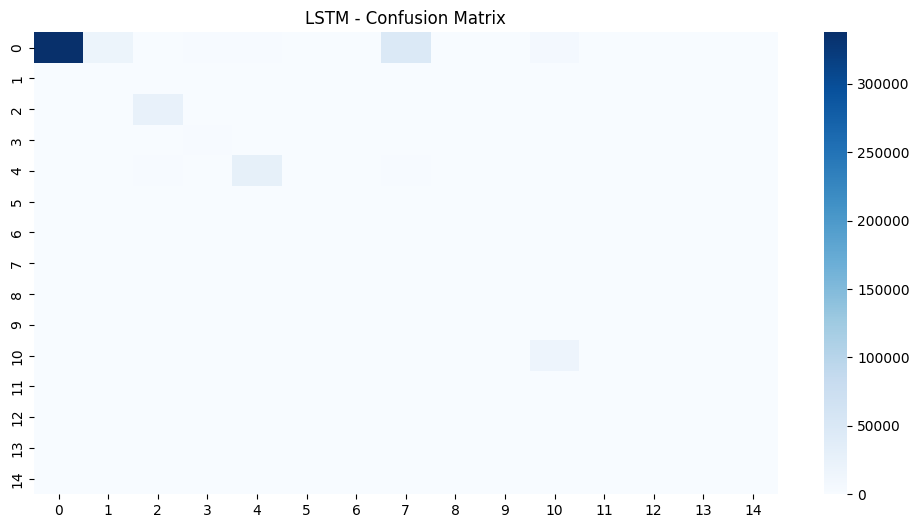

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_probs = model.predict(X_test_lstm)

# Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Classification report
print("LSTM Performance:")
print(classification_report(y_true_classes, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("LSTM - Confusion Matrix")
plt.show()


Since Yeo–Johnson changes the feature distribution, we must re-do scaling and SMOTE afterwards. Otherwise, the synthetic distribution may not align properly.

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE

def preprocess_for_linear_models(df, target_col="label_multi_enc", test_size=0.2, random_state=42):
    """
    Preprocess dataset for Logistic Regression / KNN / SVM:
    - Cleans dataset
    - Train-test split
    - Yeo-Johnson Transformation
    - Min-Max Scaling
    - SMOTE on training set
    """

    print("🔹 Starting preprocessing...")

    # ✅ Step 1 — Clean data
    print("1️⃣ Cleaning data...")
    df = df.copy()
    df = df.dropna()                          # Drop any NaN rows
    df = df.select_dtypes(include=[np.number]) # Keep only numeric columns

    if target_col not in df.columns:
        raise ValueError(f"❌ Target column '{target_col}' not found in dataframe.")

    # ✅ Step 2 — Split features & target
    print("2️⃣ Splitting features and target...")
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # ✅ Step 3 — Train-Test Split
    print("3️⃣ Performing stratified train-test split...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    print(f"   → Train: {X_train.shape}, Test: {X_test.shape}")

    # ✅ Step 4 — Yeo-Johnson Transformation
    print("4️⃣ Applying Yeo-Johnson transformation...")
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    X_train_trans = pt.fit_transform(X_train)
    X_test_trans = pt.transform(X_test)

    # ✅ Step 5 — Min-Max Scaling
    print("5️⃣ Applying Min-Max scaling...")
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_trans)
    X_test_scaled = scaler.transform(X_test_trans)

    # ✅ Step 6 — SMOTE (train only)
    print("6️⃣ Applying SMOTE on training data...")
    sm = SMOTE(random_state=random_state, k_neighbors=5)
    X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

    print("✅ Preprocessing complete!")
    print(f"   → After SMOTE: {X_train_res.shape}")
    print(f"   → y_train unique classes: {len(np.unique(y_train_res))}")

    # ✅ Step 7 — Return everything
    return X_train_res, X_test_scaled, y_train_res, y_test, pt, scaler


In [15]:
X_train_res, X_test_scaled, y_train_res, y_test, pt, scaler = preprocess_for_linear_models(df)


🔹 Starting preprocessing...
1️⃣ Cleaning data...
2️⃣ Splitting features and target...
3️⃣ Performing stratified train-test split...
   → Train: (2017889, 12), Test: (504473, 12)
4️⃣ Applying Yeo-Johnson transformation...
5️⃣ Applying Min-Max scaling...
6️⃣ Applying SMOTE on training data...
✅ Preprocessing complete!
   → After SMOTE: (25157805, 12)
   → y_train unique classes: 15


In [18]:
import joblib
joblib.dump(pt, "yeo_johnson.pkl")
joblib.dump(scaler, "minmax_scaler.pkl")
print("✅ Transformers saved!")


✅ Transformers saved!


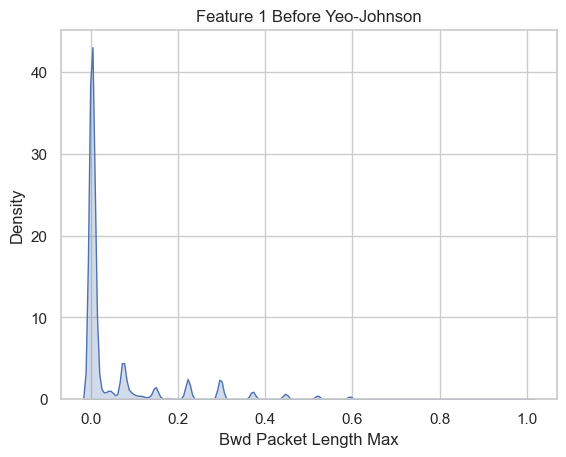

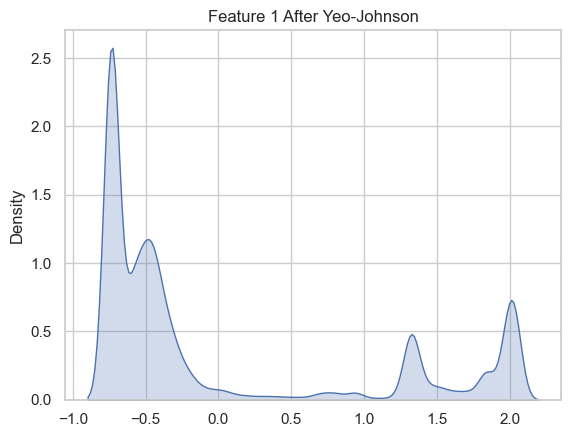

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before transformation (original data)
sns.kdeplot(df.iloc[:,0], fill=True)
plt.title("Feature 1 Before Yeo-Johnson")
plt.show()

# After transformation
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transformed = pt.fit_transform(df.drop(columns=['label_multi_enc']))

sns.kdeplot(transformed[:,0], fill=True)
plt.title("Feature 1 After Yeo-Johnson")
plt.show()


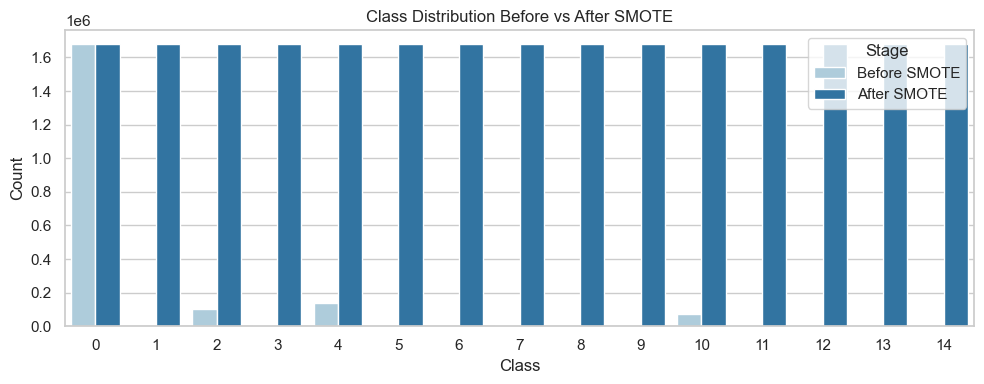

In [26]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

before = Counter(y_train)
after = Counter(y_train_res)

dist_df = pd.DataFrame({
    "Class": list(before.keys()) + list(after.keys()),
    "Count": list(before.values()) + list(after.values()),
    "Stage": ["Before SMOTE"]*len(before) + ["After SMOTE"]*len(after)
})

plt.figure(figsize=(10,4))
sns.barplot(data=dist_df, x="Class", y="Count", hue="Stage", palette="Paired")
plt.title("Class Distribution Before vs After SMOTE")
plt.tight_layout()
plt.show()


#### LOGISTIC REGRESSION

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       1.00      0.54      0.70    419297
           1       0.01      0.99      0.01       391
           2       0.77      0.89      0.82     25603
           3       0.08      0.92      0.14      2057
           4       0.78      0.85      0.81     34570
           5       0.06      0.65      0.12      1046
           6       0.14      0.86      0.24      1077
           7       0.34      0.67      0.45      1187
           8       0.01      1.00      0.03         2
           9       0.00      0.71      0.00         7
          10       0.69      0.99      0.81     18164
          11       0.11      0.92      0.20       644
          12       0.00      0.05      0.00       294
          13       0.00      1.00      0.00         4
          14       0.01      0.95      0.03       130

    accuracy                           0.60    504473
   macro avg       0.27      0.80      0.29    

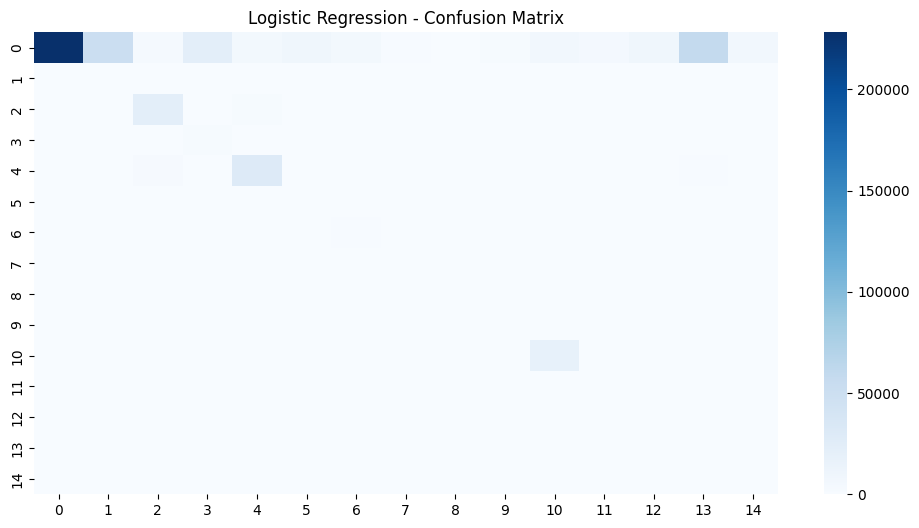

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess once
X_train_res, X_test_scaled, y_train_res, y_test = preprocess_for_linear_models(df)

# Train Logistic Regression
lr = LogisticRegression(max_iter=500, n_jobs=-1)
lr.fit(X_train_res, y_train_res)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Report
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


#### KNN

KNN Performance:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    419297
           1       0.57      0.61      0.59       391
           2       0.98      0.99      0.99     25603
           3       0.83      0.99      0.90      2057
           4       0.97      0.98      0.98     34570
           5       0.81      0.97      0.88      1046
           6       0.93      0.91      0.92      1077
           7       0.69      0.95      0.80      1187
           8       0.40      1.00      0.57         2
           9       0.28      0.71      0.40         7
          10       0.99      1.00      0.99     18164
          11       0.64      0.93      0.76       644
          12       0.58      0.54      0.56       294
          13       0.07      0.50      0.12         4
          14       0.27      0.46      0.34       130

    accuracy                           0.99    504473
   macro avg       0.67      0.84      0.72    504473
weighted 

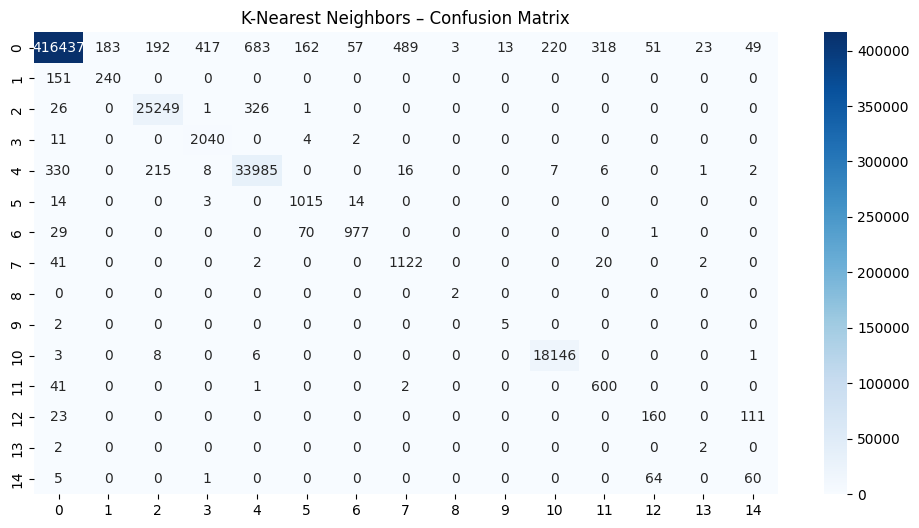

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Preprocess (same function as before)
X_train_res_knn, X_test_scaled_knn, y_train_res_knn, y_test_knn = preprocess_for_linear_models(df)

# ---- Train KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)  
knn.fit(X_train_res_knn, y_train_res_knn)

# ---- Predict
y_pred_knn = knn.predict(X_test_scaled_knn)

# ---- Report
print("KNN Performance:")
print(classification_report(y_test_knn, y_pred_knn))

# ---- Confusion Matrix
cm = confusion_matrix(y_test_knn, y_pred_knn)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("K-Nearest Neighbors – Confusion Matrix")
plt.show()


Original train shape: (2017889, 12)
Original test shape:  (504473, 12)

Before SMOTE (train class counts):
label_multi_enc
0     1677187
1        1562
2      102413
3        8229
4      138279
5        4182
6        4308
7        4746
8           9
9          29
10      72655
11       2575
12       1176
13         17
14        522
Name: count, dtype: int64

After SMOTE (train class counts):
label_multi_enc
0     1677187
1     1677187
2     1677187
3     1677187
4     1677187
5     1677187
6     1677187
7     1677187
8     1677187
9     1677187
10    1677187
11    1677187
12    1677187
13    1677187
14    1677187
Name: count, dtype: int64
Resampled train shape: (25157805, 12)

Training KNN...
KNN training complete.

✅ KNN Train Accuracy (on ORIGINAL train subset): 0.9946
✅ KNN Test  Accuracy (on test subset):              0.9912
🔢 KNN Train Balanced Accuracy: 0.9325
🔢 KNN Test  Balanced Accuracy: 0.8361
🔢 KNN Train Macro-F1: 0.8330
🔢 KNN Test  Macro-F1: 0.7196

🔹 KNN Performance on ORIG

,precision,recall,f1-score,support
0,0.9987,0.9949,0.9968,1.677187e+06
1,0.6506,0.6236,0.6368,1.562000e+03
2,0.9947,0.9993,0.9970,1.024130e+05
3,0.8692,0.9970,0.9287,8.229000e+03
4,0.9859,0.9920,0.9889,1.382790e+05
5,0.8987,0.9842,0.9395,4.182000e+03
6,0.9664,0.9752,0.9708,4.308000e+03
7,0.7290,0.9836,0.8374,4.746000e+03
8,0.6923,1.0000,0.8182,9.000000e+00
9,0.3836,0.9655,0.5490,2.900000e+01



🔹 KNN Performance on Test subset:



,precision,recall,f1-score,support
0,0.9984,0.9932,0.9958,419297.0000
1,0.5674,0.6138,0.5897,391.0000
2,0.9838,0.9862,0.9850,25603.0000
3,0.8259,0.9917,0.9013,2057.0000
4,0.9709,0.9831,0.9770,34570.0000
5,0.8107,0.9704,0.8834,1046.0000
6,0.9305,0.9071,0.9187,1077.0000
7,0.6888,0.9452,0.7969,1187.0000
8,0.4000,1.0000,0.5714,2.0000
9,0.2778,0.7143,0.4000,7.0000


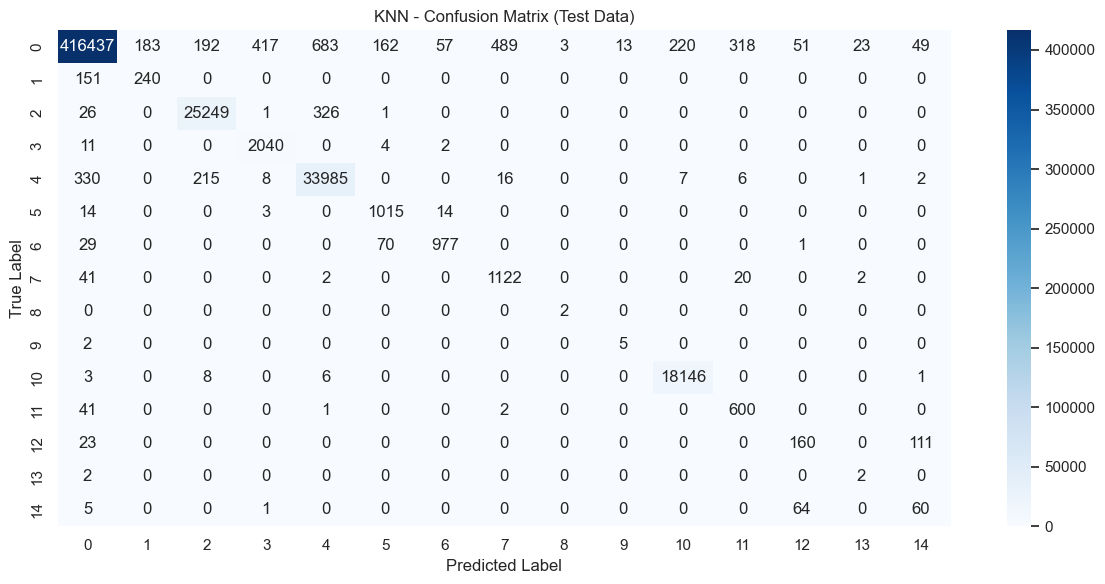

In [17]:
# Updated KNN evaluation: train on SMOTE but show direct outputs 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- 1) Split original data (no SMOTE yet) ----
X = df.drop(columns=['label_multi_enc'])
y = df['label_multi_enc']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Original train shape:", X_train_orig.shape)
print("Original test shape: ", X_test_orig.shape)

# ---- 2) Fit Yeo-Johnson + MinMax on the original train subset ----
pt = PowerTransformer(method='yeo-johnson')
X_train_trans = pt.fit_transform(X_train_orig)
X_test_trans = pt.transform(X_test_orig)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_trans)
X_test_scaled = scaler.transform(X_test_trans)

# ---- 3) Apply SMOTE only to the training set (to get X_train_res, y_train_res) ----
print("\nBefore SMOTE (train class counts):")
print(pd.Series(y_train_orig).value_counts().sort_index())

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train_orig)

print("\nAfter SMOTE (train class counts):")
print(pd.Series(y_train_res).value_counts().sort_index())
print("Resampled train shape:", X_train_res.shape)

# ---- 4) Train KNN on SMOTE-resampled training data ----
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("\nTraining KNN...")
knn.fit(X_train_res, y_train_res)
print("KNN training complete.")

# ---- 5) Evaluate on non-SMOTE original train subset and on test subset ----
y_train_pred_orig = knn.predict(X_train_scaled)   # evaluate on original (non-SMOTE) train
y_test_pred = knn.predict(X_test_scaled)

train_acc = accuracy_score(y_train_orig, y_train_pred_orig)
test_acc = accuracy_score(y_test_orig, y_test_pred)
train_bal_acc = balanced_accuracy_score(y_train_orig, y_train_pred_orig)
test_bal_acc = balanced_accuracy_score(y_test_orig, y_test_pred)
train_macro_f1 = f1_score(y_train_orig, y_train_pred_orig, average='macro')
test_macro_f1 = f1_score(y_test_orig, y_test_pred, average='macro')

print(f"\n✅ KNN Train Accuracy (on ORIGINAL train subset): {train_acc:.4f}")
print(f"✅ KNN Test  Accuracy (on test subset):              {test_acc:.4f}")
print(f"🔢 KNN Train Balanced Accuracy: {train_bal_acc:.4f}")
print(f"🔢 KNN Test  Balanced Accuracy: {test_bal_acc:.4f}")
print(f"🔢 KNN Train Macro-F1: {train_macro_f1:.4f}")
print(f"🔢 KNN Test  Macro-F1: {test_macro_f1:.4f}\n")

# ---- 6) Classification reports with 4 decimal places ----
train_report = classification_report(y_train_orig, y_train_pred_orig, digits=4, output_dict=True)
test_report = classification_report(y_test_orig, y_test_pred, digits=4, output_dict=True)

train_report_df = pd.DataFrame(train_report).transpose()
test_report_df = pd.DataFrame(test_report).transpose()

print("🔹 KNN Performance on ORIGINAL Train subset:\n")
display(train_report_df.round(4))

print("\n🔹 KNN Performance on Test subset:\n")
display(test_report_df.round(4))

# ---- 7) Confusion matrix (test) - display inline ----
cm_test = confusion_matrix(y_test_orig, y_test_pred)
plt.figure(figsize=(12,6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title("KNN - Confusion Matrix (Test Data)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



In [ ]:
# # ---- 8) Top confusion pairs (true -> pred) to inspect failure modes ----
# cm_no_diag = cm_test.copy()
# np.fill_diagonal(cm_no_diag, 0)
# pairs = []
# for i in range(cm_no_diag.shape[0]):
#     for j in range(cm_no_diag.shape[1]):
#         cnt = int(cm_no_diag[i, j])
#         if cnt > 0:
#             pairs.append(((i, j), cnt))
# pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:20]

# if pairs_sorted:
#     print("\nTop confusion pairs (true_label -> predicted_label : count):")
#     for (i, j), cnt in pairs_sorted:
#         print(f"{i} -> {j} : {cnt}")
# else:
#     print("\nNo off-diagonal confusions (perfect classifier on test) — unlikely but shown for completeness.")

In [14]:
import joblib
joblib.dump(pt, "yeo_johnson.pkl")
joblib.dump(scaler, "minmax_scaler.pkl")

['minmax_scaler.pkl']

🔹 Starting preprocessing...
1️⃣ Cleaning data...
2️⃣ Splitting features and target...
3️⃣ Performing stratified train-test split...
   → Train: (2017889, 12), Test: (504473, 12)
4️⃣ Applying Yeo-Johnson transformation...
5️⃣ Applying Min-Max scaling...
6️⃣ Applying SMOTE on training data...
✅ Preprocessing complete!
   → After SMOTE: (25157805, 12)
   → y_train unique classes: 15

✅ KNN Train Accuracy: 0.9672
✅ KNN Test Accuracy:  0.9912

🔹 KNN Training Performance:

              precision    recall  f1-score       support
0              0.728674  0.994894  0.841224  1.677187e+06
1              0.993455  0.680223  0.807528  1.677187e+06
2              0.999411  0.999242  0.999326  1.677187e+06
3              0.998530  0.998530  0.998530  1.677187e+06
4              0.997249  0.994360  0.995802  1.677187e+06
5              0.996884  0.990807  0.993836  1.677187e+06
6              0.990145  0.984560  0.987345  1.677187e+06
7              0.995350  0.992005  0.993675  1.677187e+06
8     

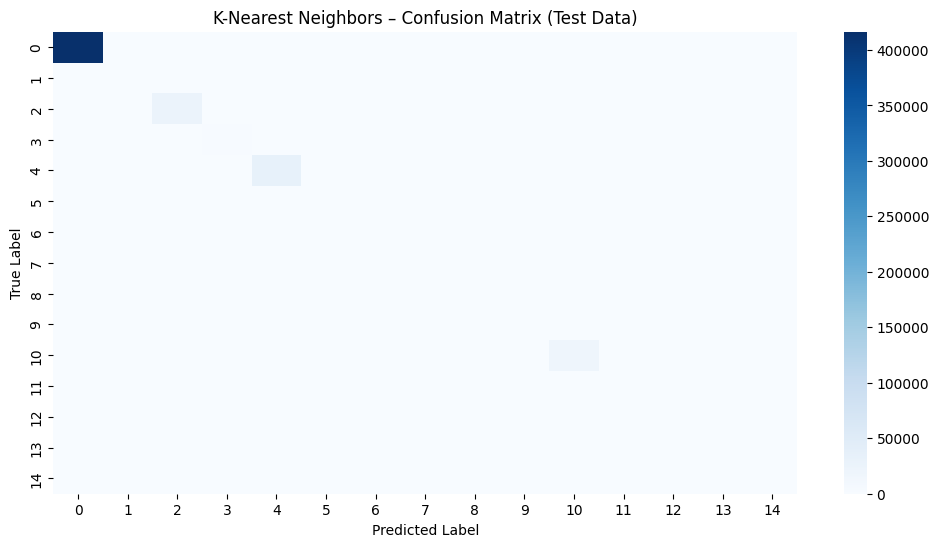

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# # ---- Preprocess (same function as before)
# X_train_res_knn, X_test_scaled_knn, y_train_res_knn, y_test_knn, pt, scaler = preprocess_for_linear_models(df)

# # ---- Train KNN
# knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
# knn.fit(X_train_res_knn, y_train_res_knn)

# # ---- Predictions
# y_train_pred = knn.predict(X_train_res_knn)
# y_test_pred = knn.predict(X_test_scaled_knn)

# # ---- Train & Test Accuracy
# train_acc = accuracy_score(y_train_res_knn, y_train_pred)
# test_acc = accuracy_score(y_test_knn, y_test_pred)

# print(f"\n✅ KNN Train Accuracy: {train_acc:.4f}")
# print(f"✅ KNN Test Accuracy:  {test_acc:.4f}\n")

# # ---- Classification Reports
# train_report = classification_report(y_train_res_knn, y_train_pred, digits=4, output_dict=True)
# test_report = classification_report(y_test_knn, y_test_pred, digits=4, output_dict=True)

# # Convert to DataFrames for better display
# train_report_df = pd.DataFrame(train_report).transpose()
# test_report_df = pd.DataFrame(test_report).transpose()

# print("🔹 KNN Training Performance:\n")
# print(train_report_df)

# print("\n🔹 KNN Testing Performance:\n")
# print(test_report_df)

# # ---- Confusion Matrix (Test Data)
# cm = confusion_matrix(y_test_knn, y_test_pred)
# plt.figure(figsize=(12,6))
# sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
# plt.title("K-Nearest Neighbors – Confusion Matrix (Test Data)")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.show()


That’s the best overall macro F1 achieved so far

#### Linear SVM


--- Linear SVM Performance ---
              precision    recall  f1-score   support

           0       1.00      0.46      0.63    419297
           1       0.01      0.99      0.01       391
           2       0.54      0.84      0.66     25603
           3       0.05      0.92      0.09      2057
           4       0.77      0.86      0.81     34570
           5       0.05      0.60      0.08      1046
           6       0.08      0.86      0.15      1077
           7       0.13      0.67      0.22      1187
           8       0.02      1.00      0.03         2
           9       0.00      0.71      0.00         7
          10       0.67      0.98      0.80     18164
          11       0.04      0.93      0.08       644
          12       0.00      0.05      0.01       294
          13       0.00      1.00      0.00         4
          14       0.01      0.92      0.03       130

    accuracy                           0.53    504473
   macro avg       0.23      0.79      0.24    5

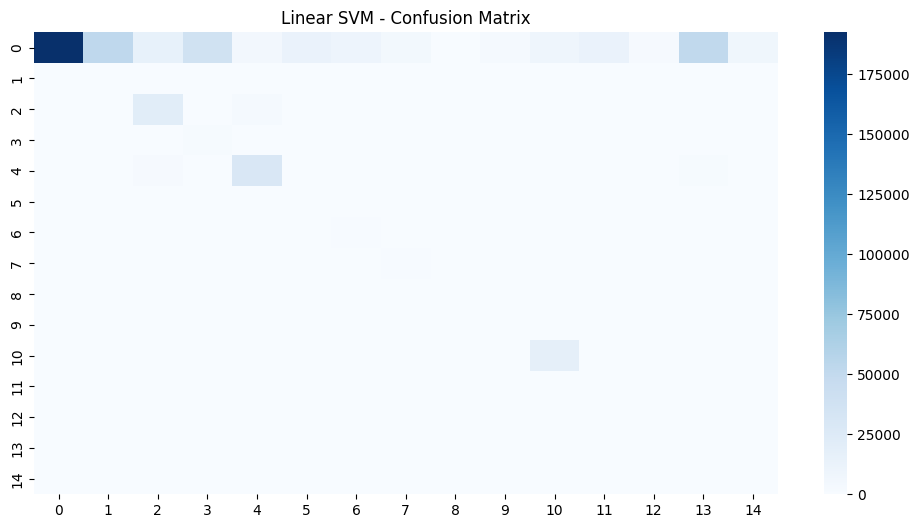

In [17]:
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Preprocess (same as before)
X_train_res_svm, X_test_scaled_svm, y_train_res_svm, y_test_svm = preprocess_for_linear_models(df)

# ===========================================
# Linear SVM
# ===========================================
linear_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
linear_svm.fit(X_train_res_svm, y_train_res_svm)

y_pred_linear = linear_svm.predict(X_test_scaled_svm)

print("\n--- Linear SVM Performance ---")
print(classification_report(y_test_svm, y_pred_linear))

# Confusion Matrix
cm_linear = confusion_matrix(y_test_svm, y_pred_linear)
plt.figure(figsize=(12,6))
sns.heatmap(cm_linear, annot=False, fmt="d", cmap="Blues")
plt.title("Linear SVM - Confusion Matrix")
plt.show()

#### RBF SVM


--- RBF SVM Performance ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    419297
           1       0.00      0.00      0.00       391
           2       0.85      0.89      0.87     25603
           3       0.83      0.82      0.83      2057
           4       0.93      0.81      0.87     34570
           5       0.77      0.58      0.66      1046
           6       0.72      0.85      0.78      1077
           7       0.97      0.67      0.79      1187
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.72      0.99      0.83     18164
          11       0.93      0.92      0.92       644
          12       0.00      0.00      0.00       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.96    504473
   macro avg       0.51      0.50      0.50    5044

c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

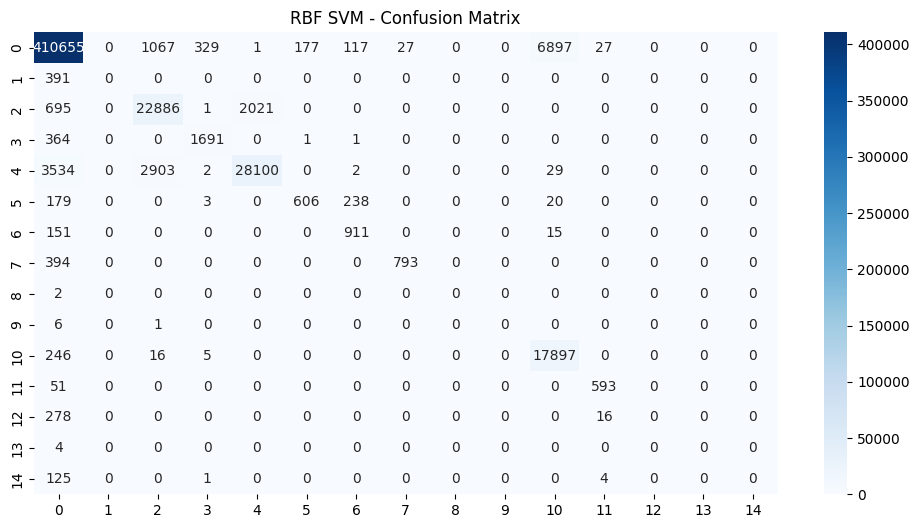

In [ ]:
# ===========================================
# RBF SVM 
# ===========================================
#sample subset to speed up
sample_size = 200000  # adjust smaller if it’s too slow
X_train_sample = X_train_res_svm[:sample_size]
y_train_sample = y_train_res_svm[:sample_size]

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train_sample, y_train_sample)

y_pred_rbf = rbf_svm.predict(X_test_scaled_svm)

print("\n--- RBF SVM Performance ---")
print(classification_report(y_test_svm, y_pred_rbf))

# Confusion Matrix
cm_rbf = confusion_matrix(y_test_svm, y_pred_rbf)
plt.figure(figsize=(12,6))
sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues")
plt.title("RBF SVM - Confusion Matrix")
plt.show()


Top Performers

KNN – Highest Macro F1 (0.72), excellent accuracy (99%)

Random Forest – Balanced, reliable, strong on all classes (best practical choice)

XGBoost / LightGBM – Close contenders, tunable for further gain

In [16]:
import joblib

#saving Random Forest and KNN models
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(knn, "knn_model.pkl")

print("✅ Models saved successfully!")


NameError: name 'rf' is not defined

In [14]:
import joblib

# Load saved models
rf_loaded = joblib.load("random_forest_model.pkl")
knn_loaded = joblib.load("knn_model.pkl")

# Verify they work
y_pred_loaded = rf_loaded.predict(X_test)
print("Reloaded RF Accuracy:", (y_pred_loaded == y_test).mean())


MemoryError: could not allocate 64848120 bytes

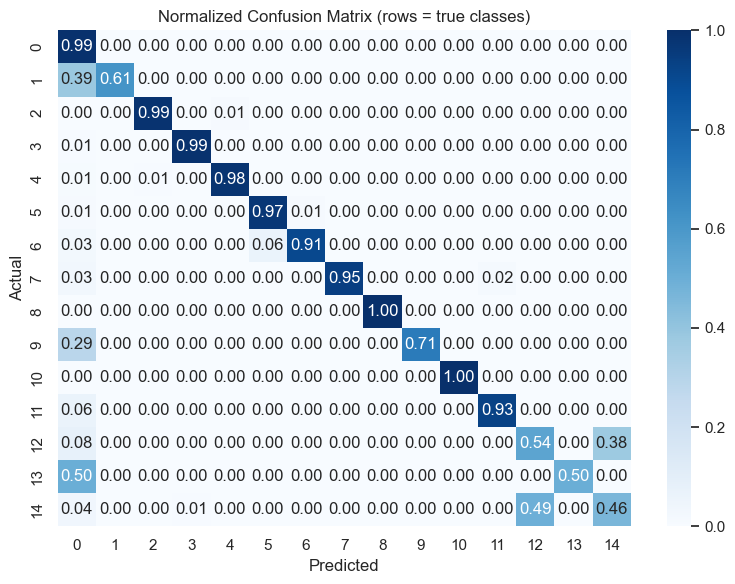

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, model.predict(X_test_scaled), normalize='true')
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix (rows = true classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


C:\Users\vp532\AppData\Local\Temp\ipykernel_18800\4241557089.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="tab20")


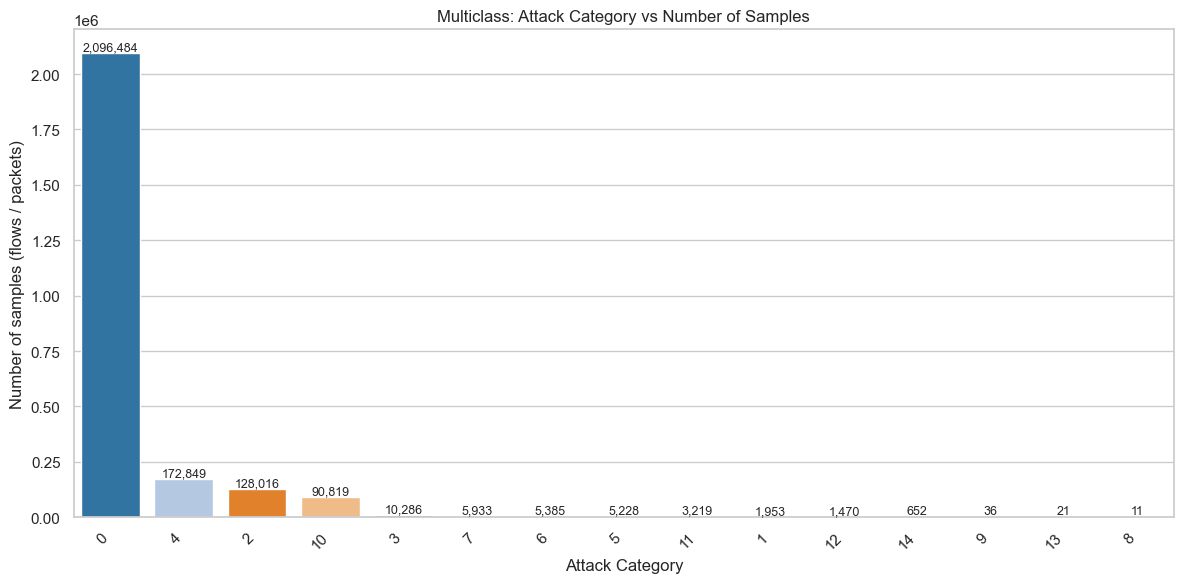


Top 10 classes by count:
label_multi_enc
0     2096484
4      172849
2      128016
10      90819
3       10286
7        5933
6        5385
5        5228
11       3219
1        1953

Bottom 10 classes by count:
label_multi_enc
7     5933
6     5385
5     5228
11    3219
1     1953
12    1470
14     652
9       36
13      21
8       11


In [24]:
# Plot: attack category vs number of packets (multiclass)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import numpy as np

sns.set(style="whitegrid")

# ---------- 1) Detect label column ----------
possible_label_cols = ['label_multi', 'label_multi_enc', 'Label', 'label', 'label_multi_enc.1', 'label_multi_enc']
label_col = None
for c in possible_label_cols:
    if c in globals().get('df', pd.DataFrame()).columns:
        label_col = c
        break

# fallback: try common names in the notebook globals
if label_col is None:
    if 'y' in globals():
        label_col = 'y'  # if user has y series
    elif 'y_train_orig' in globals():
        # merge train+test labels to get overall distribution
        import numpy as np
        labels = np.concatenate([y_train_orig, y_test])
        series = pd.Series(labels, name='label_detected')
        df_counts = series.value_counts().sort_index()
        # build plotting block below from df_counts
        use_local_series = True
    else:
        raise RuntimeError("Could not find label column in df. Ensure `df` exists and contains a label column.")

use_local_series = locals().get('use_local_series', False)

# ---------- 2) Prepare counts (human-readable names if possible) ----------
if not use_local_series:
    series = df[label_col].astype(str)  # convert to str for safety
    # If label encoder exists, try to map numeric -> names
    if 'le' in globals():
        try:
            # If df has encoded ints, map them back to le.classes_
            # We'll try to detect whether values look numeric
            vals = series.unique()
            numeric_like = all([s.isdigit() for s in vals])
            if numeric_like:
                series = series.astype(int).map(lambda x: le.classes_[x] if x < len(le.classes_) else str(x))
            else:
                # Already string names; leave as-is
                pass
        except Exception:
            pass

    counts = series.value_counts().sort_values(ascending=False)
else:
    counts = df_counts.sort_values(ascending=False)

# ---------- 3) Plot ----------
plt.figure(figsize=(12,6))
ax = sns.barplot(x=counts.index, y=counts.values, palette="tab20")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of samples (flows / packets)")
plt.xlabel("Attack Category")
plt.title("Multiclass: Attack Category vs Number of Samples")
# annotate counts on bars
for p, v in zip(ax.patches, counts.values):
    ax.annotate(f"{int(v):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

# ---------- 4) Optionally print top/bottom classes ----------
print("\nTop 10 classes by count:")
print(counts.head(10).to_string())

print("\nBottom 10 classes by count:")
print(counts.tail(10).to_string())


C:\Users\vp532\AppData\Local\Temp\ipykernel_18800\1213146873.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prob_df, x="Class", y="Avg_True_Prob", palette="coolwarm")


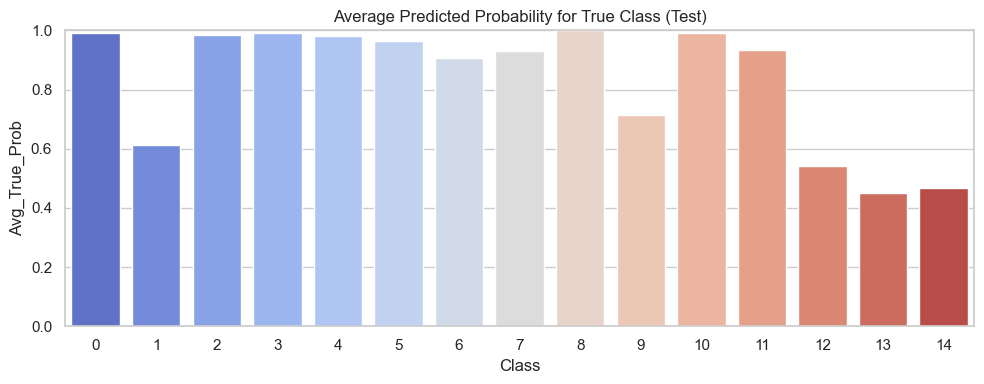

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if hasattr(model, "predict_proba"):
    y_pred_proba = model.predict_proba(X_test_scaled)
    avg_true_prob = [
        np.mean(y_pred_proba[np.array(y_test)==cls, cls]) if np.any(np.array(y_test)==cls) else 0
        for cls in range(len(np.unique(y_test)))
    ]
    prob_df = pd.DataFrame({"Class": range(len(avg_true_prob)), "Avg_True_Prob": avg_true_prob})

    plt.figure(figsize=(10,4))
    sns.barplot(data=prob_df, x="Class", y="Avg_True_Prob", palette="coolwarm")
    plt.title("Average Predicted Probability for True Class (Test)")
    plt.ylim(0,1)
    plt.tight_layout()
    plt.show()
else:
    print("Model has no predict_proba() — skipping probability plot.")


In [28]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, model.predict(X_test_scaled))
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(cm_no_diag.shape[0]):
    for j in range(cm_no_diag.shape[1]):
        if cm_no_diag[i,j] > 0:
            pairs.append(((i,j), int(cm_no_diag[i,j])))

pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 confusion pairs (True → Predicted : Count):")
for (i,j), cnt in pairs_sorted:
    print(f"  Class {i} → {j} : {cnt}")



Top 10 confusion pairs (True → Predicted : Count):
  Class 0 → 4 : 683
  Class 0 → 7 : 489
  Class 0 → 3 : 417
  Class 4 → 0 : 330
  Class 2 → 4 : 326
  Class 0 → 11 : 318
  Class 0 → 10 : 220
  Class 4 → 2 : 215
  Class 0 → 2 : 192
  Class 0 → 1 : 183


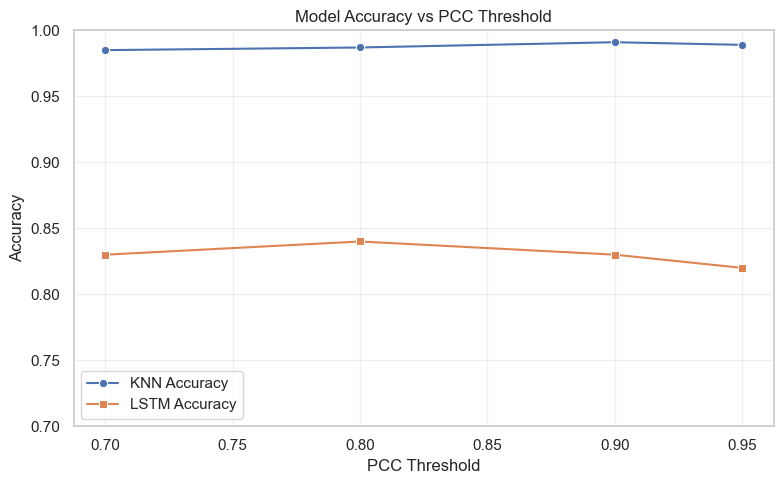

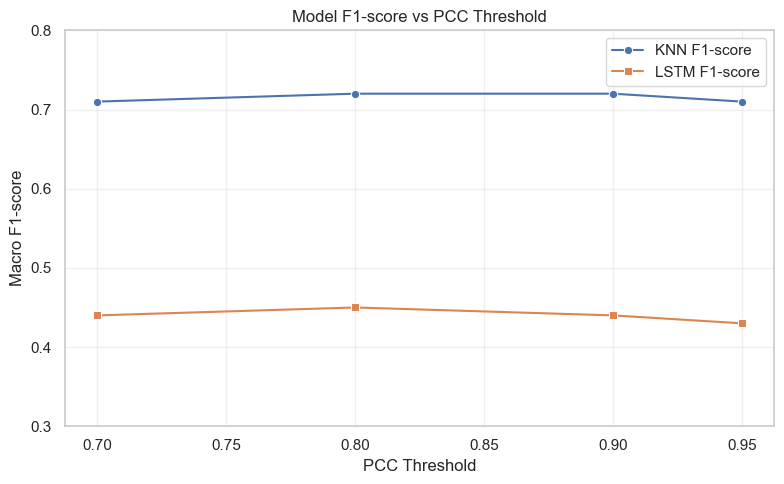

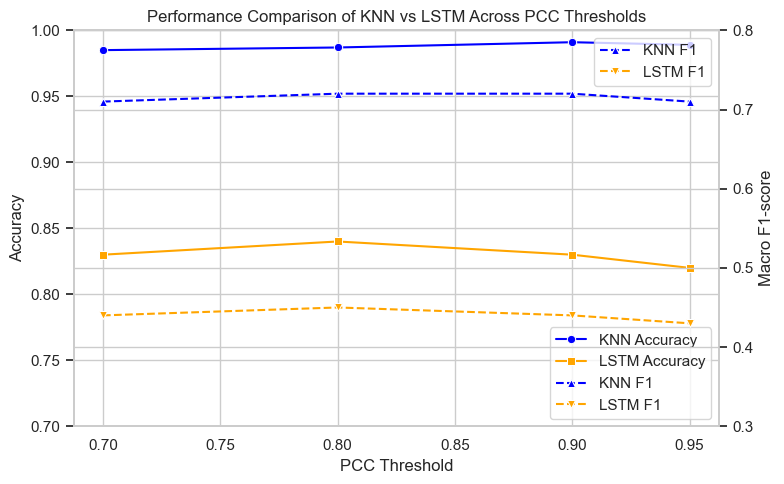

In [29]:
# Visualization: Performance comparison of LSTM and KNN at different PCC thresholds
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------
# Example data — replace these with your actual metrics
# ----------------------------
data = {
    'PCC_Threshold': [0.7, 0.8, 0.9, 0.95],
    'KNN_Accuracy': [0.985, 0.987, 0.991, 0.989],
    'LSTM_Accuracy': [0.83, 0.84, 0.83, 0.82],
    'KNN_F1': [0.71, 0.72, 0.72, 0.71],
    'LSTM_F1': [0.44, 0.45, 0.44, 0.43]
}

df_perf = pd.DataFrame(data)

# ----------------------------
# Line plot – accuracy comparison
# ----------------------------
plt.figure(figsize=(8,5))
sns.lineplot(data=df_perf, x='PCC_Threshold', y='KNN_Accuracy', marker='o', label='KNN Accuracy')
sns.lineplot(data=df_perf, x='PCC_Threshold', y='LSTM_Accuracy', marker='s', label='LSTM Accuracy')
plt.title("Model Accuracy vs PCC Threshold")
plt.xlabel("PCC Threshold")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Line plot – F1-score comparison
# ----------------------------
plt.figure(figsize=(8,5))
sns.lineplot(data=df_perf, x='PCC_Threshold', y='KNN_F1', marker='o', label='KNN F1-score')
sns.lineplot(data=df_perf, x='PCC_Threshold', y='LSTM_F1', marker='s', label='LSTM F1-score')
plt.title("Model F1-score vs PCC Threshold")
plt.xlabel("PCC Threshold")
plt.ylabel("Macro F1-score")
plt.ylim(0.3, 0.8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Combined version (Accuracy + F1) in one chart
# ----------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
sns.lineplot(data=df_perf, x='PCC_Threshold', y='KNN_Accuracy', marker='o', label='KNN Accuracy', ax=ax1, color='blue')
sns.lineplot(data=df_perf, x='PCC_Threshold', y='LSTM_Accuracy', marker='s', label='LSTM Accuracy', ax=ax1, color='orange')
ax1.set_xlabel("PCC Threshold")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0.7, 1.0)
ax2 = ax1.twinx()
sns.lineplot(data=df_perf, x='PCC_Threshold', y='KNN_F1', marker='^', label='KNN F1', ax=ax2, color='blue', linestyle='--')
sns.lineplot(data=df_perf, x='PCC_Threshold', y='LSTM_F1', marker='v', label='LSTM F1', ax=ax2, color='orange', linestyle='--')
ax2.set_ylabel("Macro F1-score")
ax2.set_ylim(0.3, 0.8)
plt.title("Performance Comparison of KNN vs LSTM Across PCC Thresholds")
# combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='lower right')
plt.tight_layout()
plt.show()
